# Many-body Ising variational optimization

This example constructs a **4×4 open array**, includes connected clusters through
**n = 3**, and optimizes an `Iz_echo → Rx → Iz_echo` sequence starting from
$|+x\rangle^{\otimes N}$. The objective is the Wineland squeezing parameter
$\xi$ (not $\xi^2$).

Select this project's **.venv** interpreter as the notebook kernel and run all
cells in order. Start the notebook from the main project folder. Saving the
result is optional and disabled below.

In [36]:
import os
# Set before importing numerical libraries; restart the kernel if changing these.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")


import numpy as np
from scipy.stats import qmc
from pathlib import Path
import matplotlib.pyplot as plt

from functions import ConstructSquareArray, OptimizationResultStore
from functions import dressing_functions_spin as df

def dB(x):
    return 10 * np.log10(x)

print("Available gates:", ConstructSquareArray.gates)

def gate_sequence_Ising(n_layers, ub_Ising):
    sequence = []
    bounds = []

    for layer in range(n_layers):
        if layer > 0:
            sequence.append("Rx")
            bounds.append((-np.pi, np.pi))

        sequence.extend(["Iz_echo", "Ix_echo"])
        bounds.extend([
            (0, ub_Ising),
            (0, ub_Ising),
        ])

    return sequence, bounds

def sample_lhs(bounds, n_samples, seed=None):
    """
    Latin-hypercube samples uniformly distributed within given bounds.

    Parameters
    ----------
    bounds : list of tuple
        [(lower_0, upper_0), (lower_1, upper_1), ...]
    n_samples : int
        Number of initial conditions to generate.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    samples : ndarray, shape (n_samples, len(bounds))
        Sampled initial conditions.
    """
    bounds = np.asarray(bounds, dtype=float)

    lower = bounds[:, 0]
    upper = bounds[:, 1]

    sampler = qmc.LatinHypercube(
        d=len(bounds),
        seed=seed,
    )

    unit_samples = sampler.random(n=n_samples)

    return qmc.scale(
        unit_samples,
        lower,
        upper,
    )

def get_single_pulse_min_time(
    arr,
):
    """
    Load or calculate the optimal time for a single Iz_echo pulse.

    Returns
    -------
    single_pulse_min_time : float
        Optimized Iz_echo pulse duration.
    """

    store = OptimizationResultStore()

    store_dir = Path(store.directory)
    store_dir.mkdir(parents=True, exist_ok=True)

    cache_file = store_dir / "single_pulse_min_time.npy"

    # # Load previously calculated value
    # if cache_file.exists():
    #     single_pulse_min_time = float(np.load(cache_file))
    #     print(
    #         f"Loaded single-pulse minimum time: "
    #         f"{single_pulse_min_time:.8g}"
    #     )
    #
    #     return single_pulse_min_time

    # Otherwise calculate it
    print("Calculating single-pulse minimum time...")

    result = arr.optimize(
        ["Iz_echo"],
        1,
        method='trust-constr',
        hessian=True,
        bounds=[(0, 1e6)],
        results_dir=store.directory,
    )

    if not result.success:
        print(
            "Warning: optimization did not report success:",
            result.message,
        )

    single_pulse_min_time = float(result.x[0])

    # Store value
    np.save(cache_file, single_pulse_min_time)

    print(
        f"Single-pulse minimum time: "
        f"{single_pulse_min_time:.8g}"
    )

    return single_pulse_min_time

Available gates: ('Rx', 'Ry', 'Rz', 'Iz', 'Iz_echo', 'Dz', 'Ix', 'Ix_echo', 'XY', 'XY_echo')


## Construct the array


`Rb` means $R_b/a$ and `Omega` means $\Omega/\Delta$. The two spatial
reflection symmetries reduce the working Hilbert space. Use
`boundary="periodic"` for minimum-image periodic distances.

In [37]:
arr = ConstructSquareArray(
    Lx=4, Ly=4, Rb=2, Omega=0.1, n=6,
    boundary="open", backend="quspin", use_reflections=True,
)
print(f"Basis: {arr.dim:,} / {arr.full_dim:,} amplitudes")
print(f"Initial squeezing xi = {arr.squeezing(arr._initial_state):.8f}")


single_pulse_min_time = get_single_pulse_min_time(arr)





Basis: 16,576 / 65,536 amplitudes
Initial squeezing xi = 1.00000000
Calculating single-pulse minimum time...
Single-pulse minimum time: 42392.402


In [41]:
dB(0.50 ** 2)

np.float64(-6.020599913279624)

In [33]:
arr.optimize(
        ["Iz_echo"],
        1,
        method='trust-constr',
        hessian=True,
        bounds=[(0, 1e6)],
    )

           message: `gtol` termination condition is satisfied.
           success: True
            status: 1
               fun: 0.5822062845465649
                 x: [ 4.239e+04]
               nit: 13
              nfev: 6
              njev: 6
              nhev: 6
          cg_niter: 5
      cg_stop_cond: 1
              grad: [ 1.748e-09]
   lagrangian_grad: [ 1.719e-09]
            constr: [array([ 4.239e+04])]
               jac: [<Compressed Sparse Row sparse array of dtype 'float64'
                    	with 1 stored elements and shape (1, 1)>]
       constr_nfev: [0]
       constr_njev: [0]
       constr_nhev: [0]
                 v: [array([-2.886e-11])]
            method: tr_interior_point
        optimality: 1.7192992851752151e-09
  constr_violation: 0.0
    execution_time: 0.05092501640319824
         tr_radius: 1202080.4285438485
    constr_penalty: 1.0
 barrier_parameter: 1.2800000000000007e-06
 barrier_tolerance: 1.2800000000000007e-06
             niter: 13

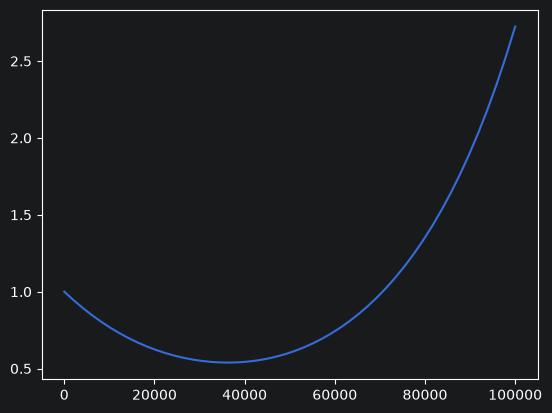

In [25]:
t = np.linspace(0, 100000)

plt.plot(t, np.array([arr.evaluate_gate_sequence_squeezing(t[i], ['Iz_echo'], False) for i in range(len(t))]))

## Run one optimization

The default below uses **L-BFGS-B with analytic gradients**. To use the analytic
Hessian, set `use_hessian = True`; the method switches to `trust-constr`.
The solver-specific option dictionaries are kept separate.

Set `save_best = True` to compare a successful final result against the saved
optimum and update it only if improved. Concurrent workers can use the same
results directory. This is a local optimization, not a global-optimum guarantee.

In [65]:
use_hessian = False
save_best = True
store = OptimizationResultStore()

method = "trust-constr" if use_hessian else "L-BFGS-B"
options = (
    {"maxiter": 150, "gtol": 1e-7, "verbose": 0}
    if use_hessian else
    {"maxiter": 150, "gtol": 1e-7, "ftol": 1e-12}
)

for l in range(5):

    gates, bounds = gate_sequence_Ising(l + 1, 3 / 2  * single_pulse_min_time)

    initial_conditions = sample_lhs(bounds, 3)

    for i in range(len(initial_conditions)):

        result = arr.optimize(
            gates, initial_conditions[i], method=method, hessian=use_hessian,
            bounds=bounds, options=options,
            results_dir=store.directory if save_best else None,
        )

        print('i:' + str(i))

    print('---------------------------------')
    print('l:' + str(l))




i:0
i:1
i:2
---------------------------------
l:0
i:0
i:1
i:2
---------------------------------
l:1
i:0
i:1
i:2
---------------------------------
l:2
i:0


KeyboardInterrupt: 

## Retrieve the optimized state and its exact gate gradients

`dpsi[k]` is $\partial |\psi\rangle/\partial\theta_k$. Both the state
and its derivatives use the working basis. Use `arr.to_full(psi)` to expand
back to the full computational basis.

In [ ]:
psi, dpsi = arr.evaluate_gate_sequence(result.x, gates, gradient=True)
print("psi shape:", psi.shape)
print("dpsi shape:", dpsi.shape)
print(f"State norm: {np.linalg.norm(psi):.12f}")
print(f"Recomputed xi: {arr.squeezing(psi):.8f}")
np.testing.assert_allclose(arr.squeezing(psi), result.fun, rtol=1e-9, atol=1e-11)